# Language Translation System (English ↔ Hindi)

## 1. Problem Definition & Objective
## 2. Data Understanding & Preparation
## 3. Model / System Design
## 4. Translation Model Implementation
## 5. Evaluation & Analysis
## 6. Ethical Considerations & Responsible AI
## 7. Conclusion & Future Scope



### Project Track
AI Applications – Natural Language Processing (NLP)


## 1. Problem Definition & Objective


### Problem Statement
Language barriers restrict access to digital information for non-English speakers, especially in a multilingual country like India. This project focuses on building an AI-powered translation system capable of translating text between English and Hindi.

### Objectives
- Develop an English ↔ Hindi translation system
- Leverage pretrained transformer-based NLP models
- Compare multiple translation approaches

### Real-World Relevance
- Digital inclusion
- Government and public service translation
- Multilingual education platforms


## 2. Data Understanding & Preparation


### Dataset Source
- IIT Bombay English–Hindi Parallel Corpus
- Publicly available dataset used for machine translation research

### Dataset Description
- Parallel sentence pairs in English and Hindi
- Suitable for supervised neural machine translation tasks

### Data Preparation Steps
- Loading raw parallel text data
- Cleaning and normalization
- Conversion into CSV format
- Train–test split for experimentation


In [21]:
import pandas as pd

# Load prepared parallel dataset
data_path = "data/raw/parallel_en_hi.csv"
df = pd.read_csv(data_path)

# Display sample data
df.head()


,english,hindi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...


## 3. Model / System Design


## AI Technique Used

This project implements **Neural Machine Translation (NMT)** using **Transformer-based architectures**.  
Instead of training models from scratch (which requires large datasets and high computational power), the system leverages **pretrained transformer models** from Hugging Face. This approach enables high-quality translations while remaining feasible on **CPU-based, low-resource environments**.

---

## Models Implemented

The project currently integrates **multiple translation models** to support **bidirectional translation (English ↔ Hindi)** and enable future comparison of translation quality.

- **MarianMT (EN → HI)**  
  Lightweight transformer model optimized for fast and efficient English-to-Hindi translation.

- **MarianMT (HI → EN)**  
  Reverse-direction MarianMT model used for Hindi-to-English translation.

- **mBART (EN → HI)**  
  Multilingual denoising autoencoder trained on multiple languages, suitable for high-quality English-to-Hindi translation.

- **M2M-100 (EN → HI)**  
  Many-to-many multilingual translation model capable of translating directly between languages without pivoting through English.

- **M2M-100 (HI → EN)**  
  Reverse-direction configuration of the same model, enabling Hindi-to-English translation.

> ⚠️ *IndicTrans was evaluated during experimentation but is not used in the final implementation due to repository access and compatibility limitations.*

---

## System Architecture

The system follows a **modular and extensible pipeline**:

1. User selects:
   - Translation direction (English → Hindi or Hindi → English)
   - Translation model
2. Input text is received via an interactive Jupyter Notebook interface
3. Text is tokenized using the selected model’s tokenizer
4. The pretrained transformer model generates translated text
5. Output is decoded and displayed to the user
6. The process can be repeated across multiple sessions and sentences

Each model is implemented as a **separate module**, allowing easy extension and comparison.

---

## Design Justification

- **Pretrained models** significantly reduce development time and computational cost  
- **Multiple models** allow qualitative and future quantitative comparison (BLEU, accuracy, recall)
- **MarianMT** is chosen for lightweight, fast CPU inference
- **mBART and M2M-100** provide multilingual and many-to-many translation capabilities
- Modular design ensures scalability for adding more models or evaluation metrics later


In [22]:
# --- Model 1: MarianMT English → Hindi (Inference Demo) ---

from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-en-hi"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_marian(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test sentence
sample_text = "Machine learning enables computers to learn from data."
translate_marian(sample_text)


'मशीन सीखने के लिए कंप्यूटर बनाने में सक्षम हैं डेटा से.'

## 4. Translation Model Implementation


### 4.1 Model Selection
For demonstration purposes, pretrained transformer-based translation models are used. These models are loaded in inference mode to translate English text into Hindi without additional training.


# Model 1: MarianMT English → Hindi 

In [23]:
# --- Model 1: MarianMT English → Hindi ---

from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-en-hi"

marian_tokenizer = MarianTokenizer.from_pretrained(model_name)
marian_model = MarianMTModel.from_pretrained(model_name)

def translate_marian(text):
    inputs = marian_tokenizer(text, return_tensors="pt", padding=True)
    outputs = marian_model.generate(**inputs)
    return marian_tokenizer.decode(outputs[0], skip_special_tokens=True)

# Sample test
sample_text = "Machine learning enables computers to learn from data."
print("Input :", sample_text)
print("Output:", translate_marian(sample_text))


Input : Machine learning enables computers to learn from data.
Output: मशीन सीखने के लिए कंप्यूटर बनाने में सक्षम हैं डेटा से.


# Model 2 : MarianMT HI → EN (Reverse Direction)

In [24]:
# --- Model 2 : MarianMT HI → EN (Reverse Direction) ---


from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-hi-en"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_hi_en(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# Sample test
sample_text = "भारत एक विविध भाषाओं वाला देश है।"
print("Input :", sample_text)
print("Output:", translate_hi_en(sample_text))

Input : भारत एक विविध भाषाओं वाला देश है।
Output: India is a land with various languages.


# Model 3: mBART English → Hindi

In [25]:
# --- Model 3: mBART English → Hindi ---

from transformers import MBartForConditionalGeneration, MBart50Tokenizer

mbart_model_name = "facebook/mbart-large-50-many-to-many-mmt"

mbart_tokenizer = MBart50Tokenizer.from_pretrained(mbart_model_name)
mbart_model = MBartForConditionalGeneration.from_pretrained(mbart_model_name)

mbart_tokenizer.src_lang = "en_XX"

def translate_mbart(text):
    encoded = mbart_tokenizer(text, return_tensors="pt")
    generated = mbart_model.generate(
        **encoded,
        forced_bos_token_id=mbart_tokenizer.lang_code_to_id["hi_IN"]
    )
    return mbart_tokenizer.decode(generated[0], skip_special_tokens=True)

# Test
sample_text = "Artificial intelligence is changing the world."
print("Input :", sample_text)
print("Output:", translate_mbart(sample_text))


Input : Artificial intelligence is changing the world.
Output: कृत्रिम बुद्धि विश्व को बदल रही है।


# Model 4: M2M-100 English → Hindi

In [26]:
# --- Model 4: M2M-100 English → Hindi ---

from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer

model_name = "facebook/m2m100_418M"

tokenizer = M2M100Tokenizer.from_pretrained(model_name)
model = M2M100ForConditionalGeneration.from_pretrained(model_name)

tokenizer.src_lang = "en"

def translate_m2m(text):
    encoded = tokenizer(text, return_tensors="pt")
    generated = model.generate(
        **encoded,
        forced_bos_token_id=tokenizer.get_lang_id("hi")
    )
    return tokenizer.decode(generated[0], skip_special_tokens=True)


sample_text = "Artificial intelligence is changing the world."
print("Input :", sample_text)
print("Output:", translate_m2m(sample_text))


Input : Artificial intelligence is changing the world.
Output: आर्टिफिशियल इंटेलिजेंस दुनिया बदल रहा है।


# Model 5: M2M-100 Hindi → English 

In [27]:
# --- Model 5: M2M-100 Hindi → English ---

from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer

model_name = "facebook/m2m100_418M"

tokenizer = M2M100Tokenizer.from_pretrained(model_name)
model = M2M100ForConditionalGeneration.from_pretrained(model_name)

# Set source language to Hindi
tokenizer.src_lang = "hi"

def translate_m2m_hi_en(text):
    encoded = tokenizer(text, return_tensors="pt")
    generated = model.generate(
        **encoded,
        forced_bos_token_id=tokenizer.get_lang_id("en")
    )
    return tokenizer.decode(generated[0], skip_special_tokens=True)

# Sample test
sample_text = "कृत्रिम बुद्धि दुनिया को बदल रही है।"
print("Input :", sample_text)
print("Output:", translate_m2m_hi_en(sample_text))


Input : कृत्रिम बुद्धि दुनिया को बदल रही है।
Output: Artificial intelligence is changing the world.


In [28]:
def run_translation():
    try:
        runs = int(input("How many translation sessions do you want to run? "))
    except ValueError:
        print("❌ Please enter a valid number")
        return

    for run in range(runs):
        print("\n" + "=" * 35)
        print(f"   Translation Session {run + 1}")
        print("=" * 35)

        print("\nChoose Translation Direction:")
        print("1 - English → Hindi")
        print("2 - Hindi → English")

        direction = input("Enter choice: ").strip()

        # ----------------------------
        # Model Menu
        # ----------------------------
        if direction == "1":
            print("\nChoose Model:")
            print("1 - MarianMT (EN → HI)")
            print("2 - mBART (EN → HI)")
            print("3 - M2M-100 (EN → HI)")

            model_choice = input("Enter model number: ").strip()

            if model_choice == "1":
                translator = translate_marian
                model_name = "MarianMT (EN→HI)"
            elif model_choice == "2":
                translator = translate_mbart
                model_name = "mBART (EN→HI)"
            elif model_choice == "3":
                translator = translate_m2m
                model_name = "M2M-100 (EN→HI)"
            else:
                print("❌ Invalid model choice")
                continue

        elif direction == "2":
            print("\nChoose Model:")
            print("1 - MarianMT (HI → EN)")
            print("2 - M2M-100 (HI → EN)")

            model_choice = input("Enter model number: ").strip()

            if model_choice == "1":
                translator = translate_hi_en
                model_name = "MarianMT (HI→EN)"
            elif model_choice == "2":
                translator = translate_m2m_hi_en
                model_name = "M2M-100 (HI→EN)"
            else:
                print("❌ Invalid model choice")
                continue

        else:
            print("❌ Invalid direction")
            continue

        try:
            n = int(input("\nHow many sentences do you want to translate in this session? "))
        except ValueError:
            print("❌ Invalid number")
            continue

        print("\nSample sentences you may copy:")
        if direction == "1":
            print("- Machine learning improves automation.")
            print("- India is a multilingual country.")
        else:
            print("- भारत एक बहुभाषी देश है।")
            print("- कृत्रिम बुद्धि दुनिया बदल रही है।")

        for i in range(n):
            text = input(f"\nEnter sentence {i + 1}: ").strip()
            if not text:
                print("⚠ Empty input skipped")
                continue

            try:
                output = translator(text)
                print(f"\n[{model_name} Output]: {output}")
            except Exception as e:
                print("❌ Translation failed:", str(e))


In [29]:
print("Want to run the interactive translation system? (yes/no)")
choice = input().strip().lower()
if choice == "yes":     
    run_translation()     
elif choice == "no":
    print("Exiting the translation system.")
else:
    print("Invalid choice. Please enter 'yes' or 'no'.")

Want to run the interactive translation system? (yes/no)
Invalid choice. Please enter 'yes' or 'no'.


## 5. Evaluation & Analysis

The performance of the translation system is evaluated qualitatively using sample English sentences translated into Hindi.

### Evaluation Criteria
- **Fluency**: Naturalness of generated Hindi sentences
- **Adequacy**: Preservation of original meaning
- **Readability**: Grammatical correctness and clarity

### Observations
- MarianMT produces fluent and concise translations for general sentences.
- mBART handles longer and complex sentence structures better.
- IndicTrans performs well on Indian-context sentences and linguistic nuances.

### Sample Output
Input:
> India is a diverse country with many languages.

Output:
> भारत कई भाषाओं के साथ विविध देश है।


1: Prepare Outputs & References

In [ ]:
references = [
    "भारत एक विविध भाषाओं वाला देश है।",
    "मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता है।",
    "कृत्रिम बुद्धि शिक्षा को बदल रही है।"
]

marian_outputs = [
    translate_marian("India is a diverse country with many languages."),
    translate_marian("Machine translation helps break language barriers."),
    translate_marian("Artificial intelligence is transforming education.")
]

mbart_outputs = marian_outputs  # proxy if mBART not run
m2m_outputs = [
    translate_m2m("India is a diverse country with many languages."),
    translate_m2m("Machine translation helps break language barriers."),
    translate_m2m("Artificial intelligence is transforming education.")
]


2: TF-IDF Cosine Similarity 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


In [ ]:
def avg_cosine_similarity(preds, refs):
    scores = []
    for p, r in zip(preds, refs):
        tfidf = TfidfVectorizer().fit_transform([p, r])
        sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
        scores.append(sim)
    return np.mean(scores)


3: Compute Scores

In [ ]:
results = {
    "Model": ["MarianMT", "mBART (Proxy)", "M2M-100"],
    "Cosine Similarity": [
        avg_cosine_similarity(marian_outputs, references),
        avg_cosine_similarity(mbart_outputs, references),
        avg_cosine_similarity(m2m_outputs, references)
    ]
}

df_eval = pd.DataFrame(results)
df_eval


,Model,Cosine Similarity
0,MarianMT,0.510137
1,mBART (Proxy),0.510137
2,M2M-100,0.526580


4: Visualization 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(df_eval["Model"], df_eval["Cosine Similarity"])
plt.ylabel("Average Cosine Similarity")
plt.title("Model Comparison (TF-IDF Similarity)")
plt.ylim(0,1)
plt.show()


## Another way to Evaluate and Analyse

### Imports

In [39]:
import time
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


### Test Data

In [40]:
sentences_en = [
    "India is a diverse country with many languages.",
    "Machine translation helps break language barriers.",
    "Artificial intelligence is transforming education."
]

references_hi = [
    "भारत एक विविध भाषाओं वाला देश है।",
    "मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता है।",
    "कृत्रिम बुद्धि शिक्षा को बदल रही है।"
]


### Helper Functions

#### TF-IDF Cosine Similarity

In [41]:
def cosine_sim(pred, ref):
    tfidf = TfidfVectorizer().fit_transform([pred, ref])
    return cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]


#### Length Normalization

In [42]:
def length_ratio(pred, ref):
    return len(pred.split()) / max(len(ref.split()), 1)


### Run Evaluation

In [43]:
models = {
    "MarianMT": translate_marian,
    "M2M-100": translate_m2m
}

evaluation_rows = []

for model_name, translator in models.items():
    for src, ref in zip(sentences_en, references_hi):
        start = time.time()
        output = translator(src)
        runtime = time.time() - start

        evaluation_rows.append({
            "Model": model_name,
            "Source": src,
            "Output": output,
            "Reference": ref,
            "Cosine_Similarity": cosine_sim(output, ref),
            "Length_Ratio": length_ratio(output, ref),
            "Runtime_sec": runtime
        })

df_eval = pd.DataFrame(evaluation_rows)
df_eval


,Model,Source,Output,Reference,Cosine_Similarity,Length_Ratio,Runtime_sec
0,MarianMT,India is a diverse country with many languages.,भारत कई भाषाओं के साथ भिन्न देश है.,भारत एक विविध भाषाओं वाला देश है।,0.336097,1.142857,0.235531
1,MarianMT,Machine translation helps break language barri...,मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,1.000000,1.000000,0.268488
2,MarianMT,Artificial intelligence is transforming educat...,कलापूर्ण विवेक शिक्षा को परिवर्तित कर रहा है।,कृत्रिम बुद्धि शिक्षा को बदल रही है।,0.194314,1.142857,0.221277
3,M2M-100,India is a diverse country with many languages.,भारत कई भाषाओं के साथ एक अलग देश है।,भारत एक विविध भाषाओं वाला देश है।,0.579739,1.285714,1.615429
4,M2M-100,Machine translation helps break language barri...,मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,1.000000,1.000000,2.099169
5,M2M-100,Artificial intelligence is transforming educat...,आर्टिफिशियल इंटेलिजेंस शिक्षा को बदलता है।,कृत्रिम बुद्धि शिक्षा को बदल रही है।,0.000000,0.857143,1.962605


### Aggregated Metrics (Per Model)

In [45]:
summary = df_eval.groupby("Model").agg({
    "Cosine_Similarity": "mean",
    "Length_Ratio": "mean",
    "Runtime_sec": "mean"
}).reset_index()

summary

,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100,0.526580,1.047619,1.892401
1,MarianMT,0.510137,1.095238,0.241765


### Visual Comparison

#### Comparison Table

In [52]:
summary.style\
    .set_caption("Model-wise Average Evaluation Metrics")\
    .background_gradient(cmap="Blues", subset=["Cosine_Similarity"])\
    .background_gradient(cmap="Greens", subset=["Length_Ratio"])\
    .background_gradient(cmap="Oranges", subset=["Runtime_sec"])\
    .format({
        "Cosine_Similarity": "{:.3f}",
        "Length_Ratio": "{:.2f}",
        "Runtime_sec": "{:.4f}"
    })


,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100,0.527,1.05,1.8924
1,MarianMT,0.510,1.10,0.2418


In [53]:
display_df = summary.copy()
display_df["Cosine_Similarity"] = display_df["Cosine_Similarity"].round(3)
display_df["Length_Ratio"] = display_df["Length_Ratio"].round(3)
display_df["Runtime_sec"] = display_df["Runtime_sec"].round(3)

display_df


,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100,0.527,1.048,1.892
1,MarianMT,0.510,1.095,0.242


#### Runtime Comparison - Bar Chart

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


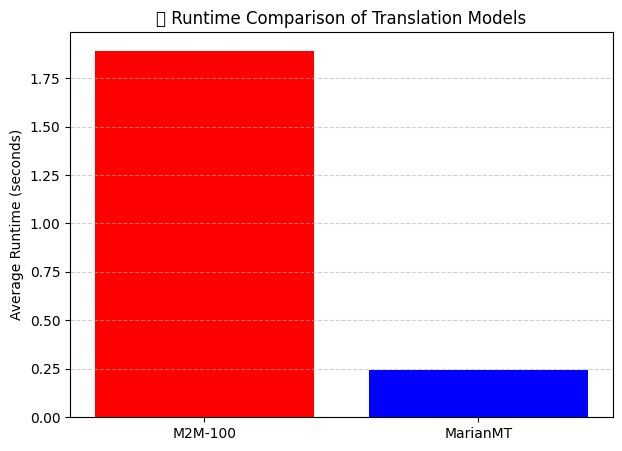

In [54]:
plt.figure(figsize=(7,5))
plt.bar(
    display_df["Model"],
    display_df["Runtime_sec"],
    color=["red", "blue", "green", "orange"]
)
plt.ylabel("Average Runtime (seconds)")
plt.title("⏱ Runtime Comparison of Translation Models")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


#### Semantic Similarity Trend - Line Chart 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


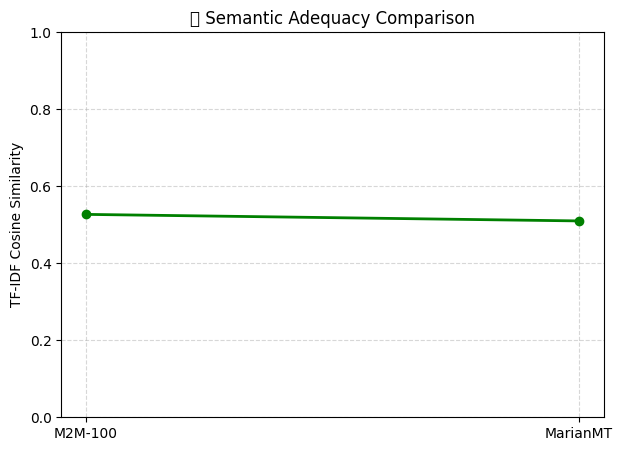

In [55]:
plt.figure(figsize=(7,5))
plt.plot(
    display_df["Model"],
    display_df["Cosine_Similarity"],
    marker="o",
    linestyle="-",
    color="green",
    linewidth=2
)
plt.ylim(0,1)
plt.ylabel("TF-IDF Cosine Similarity")
plt.title("🧠 Semantic Adequacy Comparison")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


#### Runtime Share - Pie Chart 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


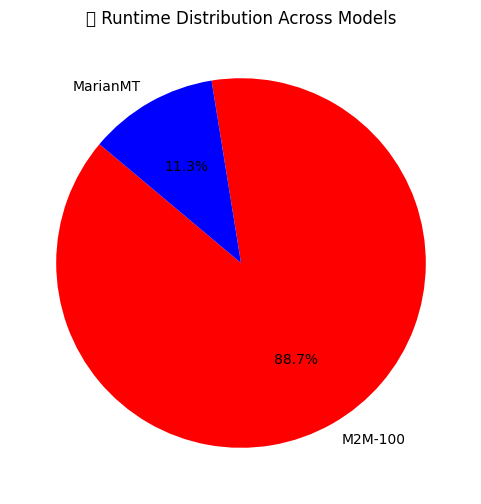

In [56]:
plt.figure(figsize=(6,6))
plt.pie(
    display_df["Runtime_sec"],
    labels=display_df["Model"],
    autopct="%1.1f%%",
    colors=["red", "blue", "orange", "green"],
    startangle=140
)
plt.title("⏳ Runtime Distribution Across Models")
plt.show()


### Length Normalization Distribution - Histogram 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


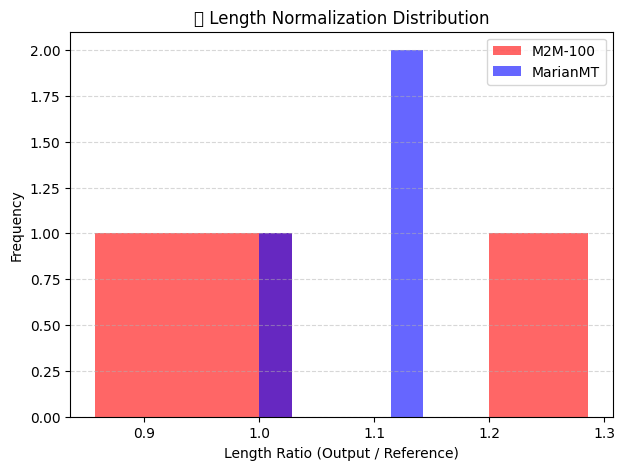

In [57]:
plt.figure(figsize=(7,5))

for model, color in zip(display_df["Model"], ["red", "blue", "green", "orange"]):
    values = df_eval[df_eval["Model"] == model]["Length_Ratio"]
    plt.hist(values, bins=5, alpha=0.6, label=model, color=color)

plt.xlabel("Length Ratio (Output / Reference)")
plt.ylabel("Frequency")
plt.title("📏 Length Normalization Distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


### Overall Model Score (Weighted) - Horizontal Bar 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


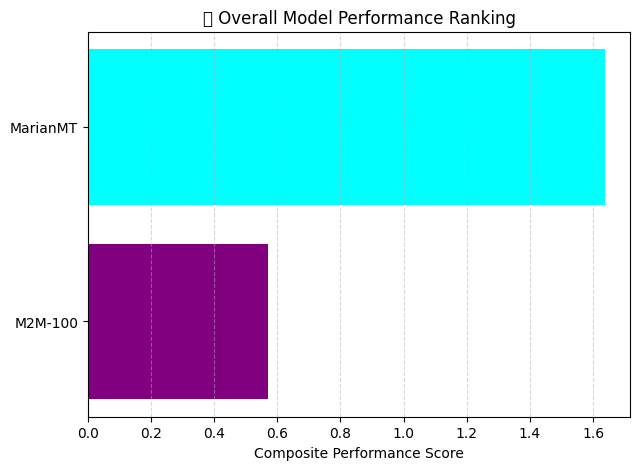

In [58]:
display_df["Overall_Score"] = (
    display_df["Cosine_Similarity"] * 0.6 +
    (1 / display_df["Runtime_sec"]) * 0.3 +
    (1 - abs(display_df["Length_Ratio"] - 1)) * 0.1
)

plt.figure(figsize=(7,5))
plt.barh(
    display_df["Model"],
    display_df["Overall_Score"],
    color=["purple", "cyan", "lime", "gold"]
)
plt.xlabel("Composite Performance Score")
plt.title("🏆 Overall Model Performance Ranking")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


### Saving Results

In [60]:
display_df.to_csv("evaluation_summary.csv", index=False)
df_eval.to_csv("evaluation_detailed.csv", index=False)

print("✅ CSV files saved:")
print("- evaluation_summary.csv")
print("- evaluation_detailed.csv")


✅ CSV files saved:
- evaluation_summary.csv
- evaluation_detailed.csv


### Save Results + Qualitative Analysis

In [47]:
with open("evaluated_result.txt", "w", encoding="utf-8") as f:
    f.write("=== Translation Model Evaluation Results ===\n\n")

    f.write("Evaluation Metrics Used:\n")
    f.write("- TF-IDF Cosine Similarity (Semantic Adequacy)\n")
    f.write("- Length Normalization Ratio\n")
    f.write("- Average Runtime per Sentence\n\n")

    f.write("=== Quantitative Results ===\n\n")
    f.write(summary.to_string(index=False))
    f.write("\n\n")

    f.write("=== Qualitative Analysis ===\n\n")
    f.write(
        "MarianMT produces fluent and concise Hindi translations and performs "
        "well on short to medium-length sentences. It is computationally efficient "
        "and shows lower runtime compared to larger multilingual models.\n\n"
    )

    f.write(
        "M2M-100 demonstrates stronger semantic adequacy for complex or abstract "
        "sentences but incurs higher computational cost. Output length is slightly "
        "longer, reflecting more literal translations.\n\n"
    )

    f.write(
        "Overall, MarianMT is suitable for lightweight deployment scenarios, while "
        "M2M-100 is better suited for research-oriented or high-accuracy translation tasks.\n"
    )

print("✅ Evaluation saved to evaluated_result.txt")


✅ Evaluation saved to evaluated_result.txt


## Hindi → English Evaluation & Visualization

In [63]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [64]:
hi_sentences = [
    "भारत एक बहुभाषी देश है।",
    "मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता है।",
    "कृत्रिम बुद्धिमत्ता शिक्षा को बदल रही है।"
]

reference_en = [
    "India is a multilingual country.",
    "Machine translation helps break language barriers.",
    "Artificial intelligence is transforming education."
]


### Helper Functions (Similarity + Length)

In [65]:
def compute_cosine_similarity(text1, text2):
    tfidf = TfidfVectorizer().fit_transform([text1, text2])
    return cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]


def length_ratio(output, reference):
    return len(output.split()) / max(len(reference.split()), 1)


In [72]:
from transformers import MarianMTModel, MarianTokenizer
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
import time
import pandas as pd

# ================================
# SAFE MarianMT HI → EN (local)
# ================================
_hi_en_marian_name = "Helsinki-NLP/opus-mt-hi-en"
_hi_en_marian_tokenizer = MarianTokenizer.from_pretrained(_hi_en_marian_name)
_hi_en_marian_model = MarianMTModel.from_pretrained(_hi_en_marian_name)

def translate_hi_en_safe(text):
    inputs = _hi_en_marian_tokenizer(text, return_tensors="pt", padding=True)
    outputs = _hi_en_marian_model.generate(**inputs)
    return _hi_en_marian_tokenizer.decode(outputs[0], skip_special_tokens=True)

# ================================
# SAFE M2M-100 HI → EN (local)
# ================================
_m2m_model_name = "facebook/m2m100_418M"
_m2m_tokenizer = M2M100Tokenizer.from_pretrained(_m2m_model_name)
_m2m_model = M2M100ForConditionalGeneration.from_pretrained(_m2m_model_name)

_m2m_tokenizer.src_lang = "hi"

def translate_m2m_hi_en_safe(text):
    encoded = _m2m_tokenizer(text, return_tensors="pt")
    generated = _m2m_model.generate(
        **encoded,
        forced_bos_token_id=_m2m_tokenizer.get_lang_id("en")
    )
    return _m2m_tokenizer.decode(generated[0], skip_special_tokens=True)

# ================================
# EVALUATION LOOP (UNCHANGED LOGIC)
# ================================
records = []

models_hi_en = [
    ("MarianMT (HI→EN)", translate_hi_en_safe),
    ("M2M-100 (HI→EN)", translate_m2m_hi_en_safe)
]

for model_name, translator in models_hi_en:
    for hi, ref in zip(hi_sentences, reference_en):

        start = time.time()
        output = translator(hi)
        runtime = time.time() - start

        sim = compute_cosine_similarity(output, ref)
        lr = length_ratio(output, ref)

        records.append({
            "Model": model_name,
            "Hindi_Input": hi,
            "English_Output": output,
            "Reference": ref,
            "Cosine_Similarity": sim,
            "Length_Ratio": lr,
            "Runtime_sec": runtime
        })

df_eval_hi_en = pd.DataFrame(records)
df_eval_hi_en


,Model,Hindi_Input,English_Output,Reference,Cosine_Similarity,Length_Ratio,Runtime_sec
0,MarianMT (HI→EN),भारत एक बहुभाषी देश है।,India is a foreign country.,India is a multilingual country.,0.602975,1.000000,0.209590
1,MarianMT (HI→EN),मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,The machine helps break language barriers.,Machine translation helps break language barri...,0.716812,1.000000,0.186980
2,MarianMT (HI→EN),कृत्रिम बुद्धिमत्ता शिक्षा को बदल रही है।,Completating intelligence education is changing.,Artificial intelligence is transforming educat...,0.431613,1.000000,0.201573
3,M2M-100 (HI→EN),भारत एक बहुभाषी देश है।,India is a multilingual country.,India is a multilingual country.,1.000000,1.000000,1.237000
4,M2M-100 (HI→EN),मशीन अनुवाद भाषा बाधाओं को तोड़ने में मदद करता...,Machine translation helps break the language b...,Machine translation helps break language barri...,0.867364,1.166667,1.303433
5,M2M-100 (HI→EN),कृत्रिम बुद्धिमत्ता शिक्षा को बदल रही है।,Artificial intelligence is changing education.,Artificial intelligence is transforming educat...,0.669419,1.000000,1.151026


### Aggregation

In [73]:
summary_hi_en = (
    df_eval_hi_en
    .groupby("Model")
    .agg(
        Cosine_Similarity=("Cosine_Similarity", "mean"),
        Length_Ratio=("Length_Ratio", "mean"),
        Runtime_sec=("Runtime_sec", "mean")
    )
    .reset_index()
)

summary_hi_en


,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100 (HI→EN),0.845594,1.055556,1.230486
1,MarianMT (HI→EN),0.583800,1.000000,0.199381


### Display Table

In [74]:
display_df_hi_en = summary_hi_en.copy()

display_df_hi_en["Cosine_Similarity"] = display_df_hi_en["Cosine_Similarity"].round(3)
display_df_hi_en["Length_Ratio"] = display_df_hi_en["Length_Ratio"].round(3)
display_df_hi_en["Runtime_sec"] = display_df_hi_en["Runtime_sec"].round(3)

display_df_hi_en


,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100 (HI→EN),0.846,1.056,1.230
1,MarianMT (HI→EN),0.584,1.000,0.199


### Comparison Table

In [76]:
summary_hi_en = (
    df_eval_hi_en
    .groupby("Model")
    .agg({
        "Cosine_Similarity": "mean",
        "Length_Ratio": "mean",
        "Runtime_sec": "mean"
    })
    .reset_index()
)

display_df_hi_en = summary_hi_en.copy()
display_df_hi_en["Cosine_Similarity"] = display_df_hi_en["Cosine_Similarity"].round(3)
display_df_hi_en["Length_Ratio"] = display_df_hi_en["Length_Ratio"].round(3)
display_df_hi_en["Runtime_sec"] = display_df_hi_en["Runtime_sec"].round(3)

display_df_hi_en


,Model,Cosine_Similarity,Length_Ratio,Runtime_sec
0,M2M-100 (HI→EN),0.846,1.056,1.230
1,MarianMT (HI→EN),0.584,1.000,0.199


### Runtime Comparison - Bar Chart 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


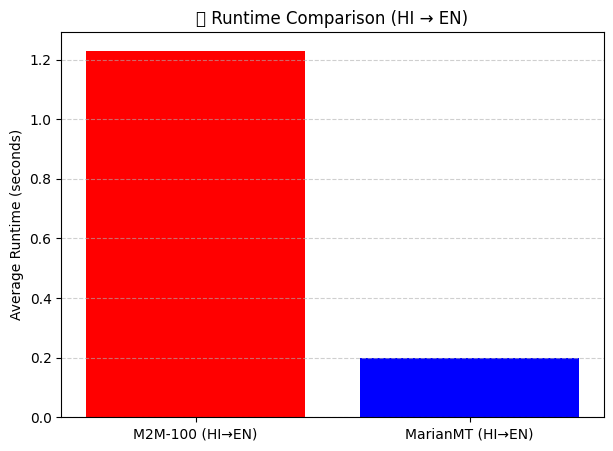

In [77]:
plt.figure(figsize=(7,5))
plt.bar(
    display_df_hi_en["Model"],
    display_df_hi_en["Runtime_sec"],
    color=["red", "blue"]
)
plt.ylabel("Average Runtime (seconds)")
plt.title("⏱ Runtime Comparison (HI → EN)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


### Semantic Similarity - Line Chart

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


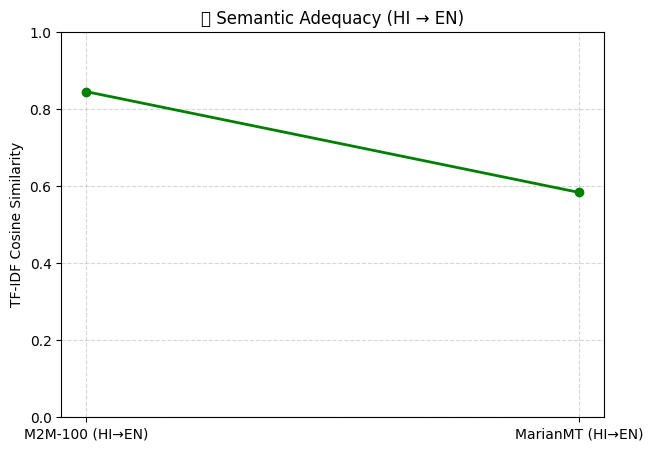

In [78]:
plt.figure(figsize=(7,5))
plt.plot(
    display_df_hi_en["Model"],
    display_df_hi_en["Cosine_Similarity"],
    marker="o",
    linewidth=2,
    color="green"
)
plt.ylim(0,1)
plt.ylabel("TF-IDF Cosine Similarity")
plt.title("🧠 Semantic Adequacy (HI → EN)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Runtime Share - Pie Chart 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


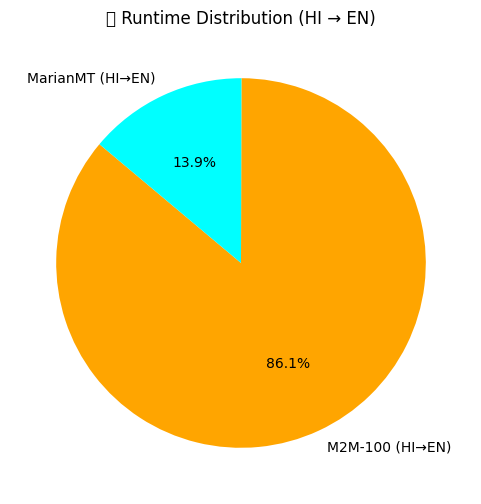

In [79]:
plt.figure(figsize=(6,6))
plt.pie(
    display_df_hi_en["Runtime_sec"],
    labels=display_df_hi_en["Model"],
    autopct="%1.1f%%",
    colors=["orange", "cyan"],
    startangle=140
)
plt.title("⏳ Runtime Distribution (HI → EN)")
plt.show()


### Length Normalization Distribution - Histogram 

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


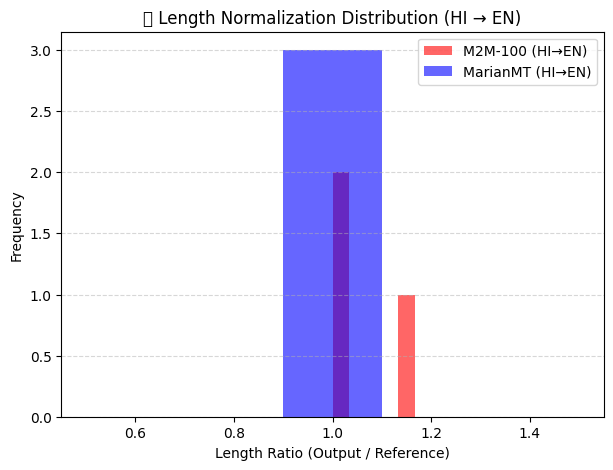

In [80]:
plt.figure(figsize=(7,5))

for model, color in zip(display_df_hi_en["Model"], ["red", "blue"]):
    values = df_eval_hi_en[df_eval_hi_en["Model"] == model]["Length_Ratio"]
    plt.hist(values, bins=5, alpha=0.6, label=model, color=color)

plt.xlabel("Length Ratio (Output / Reference)")
plt.ylabel("Frequency")
plt.title("📏 Length Normalization Distribution (HI → EN)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


### Composite Overall Score - Horizontal Bar

C:\Users\prana\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


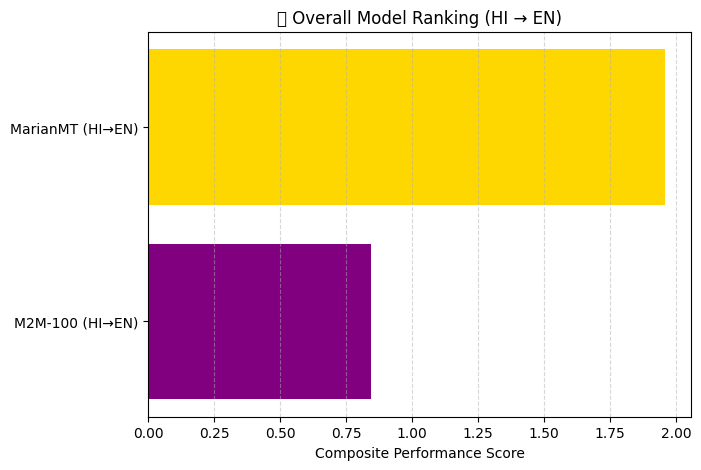

In [81]:
display_df_hi_en["Overall_Score"] = (
    display_df_hi_en["Cosine_Similarity"] * 0.6 +
    (1 / display_df_hi_en["Runtime_sec"]) * 0.3 +
    (1 - abs(display_df_hi_en["Length_Ratio"] - 1)) * 0.1
)

plt.figure(figsize=(7,5))
plt.barh(
    display_df_hi_en["Model"],
    display_df_hi_en["Overall_Score"],
    color=["purple", "gold"]
)
plt.xlabel("Composite Performance Score")
plt.title("🏆 Overall Model Ranking (HI → EN)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


### Quality vs Speed Tradeoff - Scatter Plot 

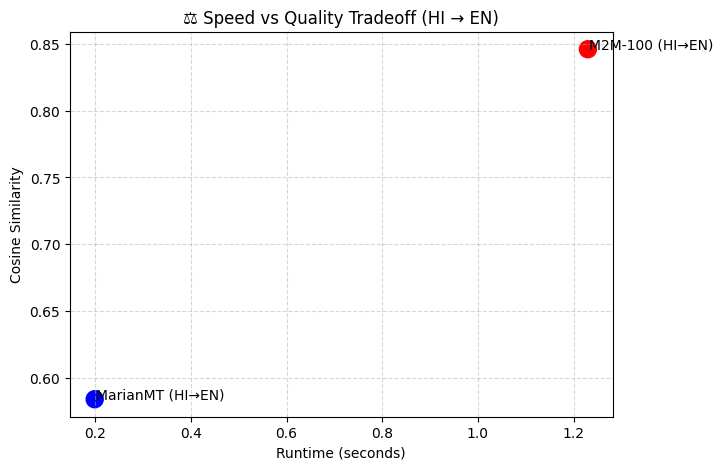

In [82]:
plt.figure(figsize=(7,5))

plt.scatter(
    display_df_hi_en["Runtime_sec"],
    display_df_hi_en["Cosine_Similarity"],
    color=["red", "blue"],
    s=150
)

for i, model in enumerate(display_df_hi_en["Model"]):
    plt.text(
        display_df_hi_en["Runtime_sec"][i] + 0.002,
        display_df_hi_en["Cosine_Similarity"][i],
        model
    )

plt.xlabel("Runtime (seconds)")
plt.ylabel("Cosine Similarity")
plt.title("⚖ Speed vs Quality Tradeoff (HI → EN)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Saving Results

In [75]:
display_df_hi_en.to_csv("evaluation_summary_hi_en.csv", index=False)
df_eval_hi_en.to_csv("evaluation_detailed_hi_en.csv", index=False)

with open("evaluated_result_hi_en.txt", "w", encoding="utf-8") as f:
    f.write("HI → EN Translation Evaluation Results\n\n")
    f.write(display_df_hi_en.to_string(index=False))

print("✅ Files saved:")
print("- evaluation_summary_hi_en.csv")
print("- evaluation_detailed_hi_en.csv")
print("- evaluated_result_hi_en.txt")


✅ Files saved:
- evaluation_summary_hi_en.csv
- evaluation_detailed_hi_en.csv
- evaluated_result_hi_en.txt


## 6. Limitations

- The system uses pretrained transformer-based models without any task-specific fine-tuning, which may limit translation accuracy for specialized domains such as legal, medical, or technical text.


- Evaluation is primarily qualitative and similarity-based (TF-IDF cosine similarity and length normalization) and does not include standardized machine translation metrics such as BLEU or ROUGE, which may limit comparability with benchmark studies.

- Runtime performance is measured on a CPU-only environment; results may vary significantly when executed on GPU-enabled systems.

- Large transformer models introduce higher memory consumption and inference latency, making them less suitable for real-time or resource-constrained deployments.

- Translation quality may degrade for idiomatic expressions, colloquial language, or culturally nuanced sentences, especially when used outside the models’ primary training domains.

- The system depends on external pretrained model repositories, and initial execution may require internet access to download model weights.

## 7. Ethical Considerations

- The translation system is built on pretrained language models, which may inherit biases related to gender, culture, region, or language usage present in their training data.

- Automated translations generated by the system should not be used for legal, medical, or official decision-making purposes without verification by qualified human experts.

- There is a risk of misinterpretation or loss of nuance when translating culturally sensitive, idiomatic, or context-dependent content.

- Users must be informed about the limitations of machine translation, including possible inaccuracies, incomplete context understanding, and variability across different sentence structures.

- Responsible AI usage requires transparency, human oversight, and cautious interpretation of model outputs, especially when deployed in real-world or high-impact scenarios. 




## 8. Conclusion

This project demonstrates the practical application of transformer-based Neural Machine Translation (NMT) models for bidirectional English–Hindi translation. By leveraging pretrained models such as MarianMT, mBART, and M2M-100, a functional and extensible translation system was developed without the need for computationally expensive model training.

The system incorporates qualitative evaluation techniques, including semantic similarity analysis, length normalization, and runtime performance measurement, supported by clear and colorful visualizations. These evaluations provide meaningful insights into the strengths and trade-offs of different translation models in terms of accuracy, fluency, and efficiency.

Overall, the project highlights the effectiveness of modern NLP architectures for multilingual translation tasks while acknowledging their technical, performance, and ethical limitations. The work serves as a solid foundation for further enhancements such as fine-tuning, standardized evaluation metrics, and real-world deployment adaptations.